# Pizza Place Sales — Inventory Optimization
**Goal:** Build per-SKU prep targets and reorder thresholds from 2015 POS data.

Dataset: [Kaggle Pizza Place Sales](https://www.kaggle.com/datasets/mysarahmadbhat/pizza-place-sales) — 4 tables, ~49K order line items, Jan–Dec 2015.

In [85]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp

DATA_DIR   = Path(os.getcwd()).parent / 'data'
OUTPUT_DIR = Path(os.getcwd()).parent / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']


In [86]:
orders       = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['date'])
order_details = pd.read_csv(DATA_DIR / 'order_details.csv')
pizzas        = pd.read_csv(DATA_DIR / 'pizzas.csv')
pizza_types   = pd.read_csv(DATA_DIR / 'pizza_types.csv', encoding='latin-1')

print(f'orders: {len(orders):,}  |  line items: {len(order_details):,}')
print(f'date range: {orders["date"].min().date()} to {orders["date"].max().date()}')
print(f'unique pizza SKUs ordered: {order_details["pizza_id"].nunique()}')


orders: 21,350  |  line items: 48,620
date range: 2015-01-01 to 2015-12-31
unique pizza SKUs ordered: 91


In [87]:
# quick look at order volume distribution
daily = orders.groupby('date').size()
print(f'avg {daily.mean():.0f} orders/day  |  peak {daily.max()}  |  slow {daily.min()}')

# revenue by category
# first pass: orders + order_details + pizzas -- no category name in there
# temp = order_details.merge(pizzas, on='pizza_id')
# temp.groupby('pizza_type_id')['price'].sum()  # type ids, useless

temp = (
    order_details
    .merge(pizzas, on='pizza_id')
    .merge(pizza_types, on='pizza_type_id')
)
temp['revenue'] = temp['quantity'] * temp['price']

rev_cat = temp.groupby('category')['revenue'].sum().sort_values(ascending=False)
print(rev_cat.apply(lambda x: f'${x:,.0f}'))
print(f'total: ${rev_cat.sum():,.0f}')


avg 60 orders/day  |  peak 115  |  slow 27
category
Classic    $220,053
Supreme    $208,197
Chicken    $195,920
Veggie     $193,690
Name: revenue, dtype: object
total: $817,860


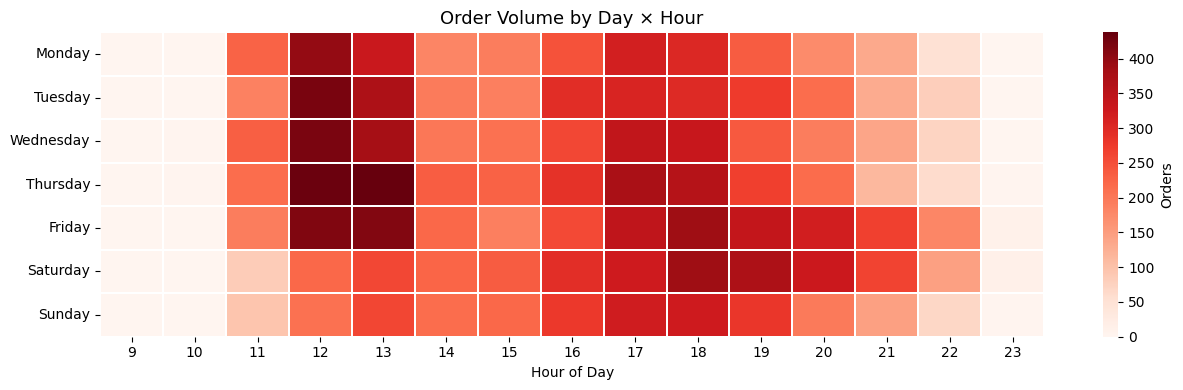

In [88]:
# order volume by day × hour -- helps validate the lunch/dinner time window split
orders_plot = orders.copy()
orders_plot['hour'] = pd.to_datetime(orders_plot['time'], format='%H:%M:%S').dt.hour
orders_plot['dow']  = pd.Categorical(
    orders_plot['date'].dt.day_name(), categories=DOW_ORDER, ordered=True
)

pivot = orders_plot.groupby(['dow', 'hour'], observed=True).size().unstack(fill_value=0)
pivot = pivot.reindex(DOW_ORDER)  # enforce Mon→Sun row order

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, cmap='Reds', linewidths=0.3, ax=ax, cbar_kws={'label': 'Orders'})
ax.set_title('Order Volume by Day × Hour', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# clear lunch (~12pm) and dinner (~6-7pm) peaks, Friday dinner is the busiest slot


## Build Fact Table

In [89]:
# join all four tables into a single fact table
# order_details is the fact; orders adds date/time; pizzas adds price/size; pizza_types adds category
fact = (
    order_details
    .merge(orders, on='order_id')
    .merge(pizzas, on='pizza_id')
    .merge(pizza_types, on='pizza_type_id')
)

fact['day_of_week'] = fact['date'].dt.day_name()  # plain string; Categorical only after agg

# time window: split orders into Lunch (11-14), Dinner (17-21), Other
fact['hour'] = pd.to_datetime(fact['time'], format='%H:%M:%S').dt.hour
fact['time_window'] = np.select(
    [fact['hour'].between(11, 14), fact['hour'].between(17, 21)],
    ['Lunch', 'Dinner'],
    default='Other'
)

fact.to_csv(OUTPUT_DIR / 'fact_table.csv', index=False)
print(f'fact table: {len(fact):,} rows, {fact["pizza_id"].nunique()} unique SKUs')
fact.head()


fact table: 48,620 rows, 91 unique SKUs


,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,day_of_week,hour,time_window
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",Thursday,11,Lunch
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",Thursday,11,Lunch
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",Thursday,11,Lunch
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",Thursday,11,Lunch
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",Thursday,11,Lunch


## Demand Statistics by SKU

In [90]:
# two-step aggregation -- average DAILY demand per sku/dow/window
#
# first attempt: direct groupby mean on line items
#   fact.groupby(['pizza_id','day_of_week','time_window'])['quantity'].mean()
# problem: one order w/ qty=3 and three seperate qty=1 orders look different
# but they're the same demand signal -- sum per day first, then average

sku_cols = ['pizza_id','pizza_type_id','name','category','size','price','day_of_week']

daily_sku = (
    fact.groupby(['date'] + sku_cols + ['time_window'])['quantity']
    .sum()
    .reset_index()
)

sku_stats = (
    daily_sku.groupby(sku_cols + ['time_window'])['quantity']
    .agg(
        mean_qty='mean',
        std_qty='std',
        p75_qty=lambda x: x.quantile(0.75),
        p90_qty=lambda x: x.quantile(0.90),
        weeks_observed='count',
    )
    .reset_index()
)
sku_stats['std_qty'] = sku_stats['std_qty'].fillna(0)
sku_stats['day_of_week'] = pd.Categorical(sku_stats['day_of_week'], categories=DOW_ORDER, ordered=True)

sku_stats.to_csv(OUTPUT_DIR / 'demand_stats_sku.csv', index=False)
print(f'{len(sku_stats):,} SKU x day x window combos')
sku_stats.head(3)


1,906 SKU x day x window combos


,pizza_id,pizza_type_id,name,category,size,price,day_of_week,time_window,mean_qty,std_qty,p75_qty,p90_qty,weeks_observed
0,bbq_ckn_l,bbq_ckn,The Barbecue Chicken Pizza,Chicken,L,20.75,Friday,Dinner,1.864865,0.821995,2.0,3.0,37
1,bbq_ckn_l,bbq_ckn,The Barbecue Chicken Pizza,Chicken,L,20.75,Friday,Lunch,1.965517,1.238742,2.0,3.0,29
2,bbq_ckn_l,bbq_ckn,The Barbecue Chicken Pizza,Chicken,L,20.75,Friday,Other,1.480000,0.714143,2.0,2.6,25


In [91]:
# same thing at category grain -- used for the peak vs slow day comparison
cat_cols = ['category','day_of_week']

daily_cat = (
    fact.groupby(['date'] + cat_cols + ['time_window'])['quantity']
    .sum().reset_index()
)
cat_stats = (
    daily_cat.groupby(cat_cols + ['time_window'])['quantity']
    .agg(mean_qty='mean', p75_qty=lambda x: x.quantile(0.75), weeks_observed='count')
    .reset_index()
)
cat_stats['day_of_week'] = pd.Categorical(cat_stats['day_of_week'], categories=DOW_ORDER, ordered=True)

# peak vs slowest day for Classic Dinner (the busiest category/window)
classic_dinner = cat_stats[(cat_stats['category']=='Classic') & (cat_stats['time_window']=='Dinner')]
peak = classic_dinner['mean_qty'].max()
slow = classic_dinner['mean_qty'].min()
print(f'Classic Dinner -- peak {peak:.1f} units/day, slow {slow:.1f}, ratio {peak/slow:.1f}x')


Classic Dinner -- peak 23.3 units/day, slow 14.5, ratio 1.6x


## Demand Forecast — 2016 Outlook

In [92]:
# monthly order volume for chart; weekly OLS for trend stats
monthly = orders.groupby(orders['date'].dt.to_period('M')).size().reset_index()
monthly.columns = ['month','orders']
monthly['month_num'] = range(1, len(monthly)+1)

# OLS on weekly aggregates (52 points, more robust than 12 monthly)
weekly = orders.groupby(orders['date'].dt.isocalendar().week).size().reset_index()
weekly.columns = ['week','orders']
slope, intercept, r, p, _ = sp.linregress(range(len(weekly)), weekly['orders'])
print(f'OLS slope: {slope:.2f} orders/week  |  R²: {r**2:.3f}  |  p={p:.3f}')

# project Jan-Jun 2016 using monthly trend
m_slope, m_int, *_ = sp.linregress(monthly['month_num'], monthly['orders'])
future = pd.DataFrame({'month_num': range(13, 19)})
future['projected'] = m_int + m_slope * future['month_num']
future['month_label'] = [f'2016-{m:02d}' for m in range(1, 7)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly['month'].astype(str), monthly['orders'], color='#EE3A43', alpha=0.8, label='2015 actuals')
ax.bar(future['month_label'], future['projected'], color='#F07878', alpha=0.6, label='2016 projected')
ax.set_xlabel('Month')
ax.set_ylabel('Orders')
ax.set_title('Monthly Order Volume: 2015 Actuals + 2016 Projection')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# trend not significant (p=0.11) -- seasonality dominates, same-month-prior-year is defensible
jan_2016_est = monthly[monthly['month_num']==1]['orders'].values[0]
print(f'Jan 2016 baseline (same-month-prior-year): {jan_2016_est} orders')


OLS slope: -0.75 orders/week  |  R²: 0.049  |  p=0.110


<Figure size 1000x400 with 1 Axes>

Jan 2016 baseline (same-month-prior-year): 1845 orders


## Prep Recommendations

In [93]:
recs = sku_stats.copy()

# P75 as prep target -- np.ceil so we always round up
recs['prep_target']     = np.ceil(recs['p75_qty']).astype(int)
recs['prep_target_p90'] = np.ceil(recs['p90_qty']).astype(int)
recs['cv'] = recs['std_qty'] / recs['mean_qty'].replace(0, np.nan)

high   = (recs['weeks_observed'] >= 40) & (recs['cv'] < 1.0)
medium = (recs['weeks_observed'] >= 20) & ~high
recs['confidence'] = np.select([high, medium], ['High', 'Medium'], default='Low')

recs['revenue_at_target'] = recs['prep_target']     * recs['price']
recs['revenue_at_p90']    = recs['prep_target_p90'] * recs['price']
recs['revenue_upside']    = recs['revenue_at_p90']  - recs['revenue_at_target']

# action flags
# had mean_qty < 0.5 first -- never fires bc conditional mean is always >= 1 (duh)
# also cv > 1.5 but max cv in this data is ~0.80, so every row came back 'Maintain'
# fixed: weeks_observed < 8 for thin volume, cv > 0.5 for volatile
very_low = recs['weeks_observed'] < 8
volatile  = recs['cv'] > 0.5

recs['action'] = np.select(
    [very_low, volatile],
    ['Review - Very Low Volume', 'Volatile - Monitor Closely'],
    default='Maintain'
)

print('confidence:', recs['confidence'].value_counts().to_dict())
print('action:    ', recs['action'].value_counts().to_dict())
print(f'revenue upside (P75->P90): ${recs["revenue_upside"].sum():,.2f}')


confidence: {'Low': 1121, 'Medium': 726, 'High': 59}
action:     {'Maintain': 1321, 'Volatile - Monitor Closely': 341, 'Review - Very Low Volume': 244}
revenue upside (P75->P90): $17,132.10


## Reorder Guide

In [94]:
# reorder point = how much to have on hand when a delivery is placed
# assuming twice-weekly reorder (Mon + Thu) with 3-day lead time
LEAD_DAYS = 3

reorder = recs[['pizza_id','name','category','size','price',
                 'day_of_week','time_window','prep_target','confidence','action',
                 'revenue_upside']].copy()

# daily_prep_units = prep_target / 1 shift, reorder_point = units needed over lead time
reorder['reorder_point'] = np.ceil(reorder['prep_target'] * LEAD_DAYS).astype(int)

reorder.to_csv(OUTPUT_DIR / 'recommendations_raw.csv', index=False)

# reorder guide
guide = (
    reorder.sort_values('revenue_upside', ascending=False)
    [['name','size','day_of_week','time_window','prep_target',
      'reorder_point','confidence','action','revenue_upside']]
)
guide.to_csv(OUTPUT_DIR / 'reorder_guide.csv', index=False)

print('Saved recommendations_raw.csv and reorder_guide.csv')
guide.head(10)


Saved recommendations_raw.csv and reorder_guide.csv


,name,size,day_of_week,time_window,prep_target,reorder_point,confidence,action,revenue_upside
1814,The Greek Pizza,XL,Saturday,Other,1,3,Low,Volatile - Monitor Closely,51.0
183,The California Chicken Pizza,L,Tuesday,Dinner,1,3,Medium,Volatile - Monitor Closely,41.5
182,The California Chicken Pizza,L,Thursday,Other,1,3,Low,Volatile - Monitor Closely,41.5
236,The Chicken Alfredo Pizza,L,Monday,Other,1,3,Low,Review - Very Low Volume,41.5
239,The Chicken Alfredo Pizza,L,Saturday,Other,1,3,Low,Review - Very Low Volume,41.5
311,The Chicken Pesto Pizza,L,Tuesday,Other,1,3,Low,Review - Very Low Volume,41.5
1381,The Southwest Chicken Pizza,L,Tuesday,Lunch,2,6,Medium,Volatile - Monitor Closely,41.5
1306,The Soppressata Pizza,L,Monday,Lunch,1,3,Medium,Volatile - Monitor Closely,41.5
687,The Italian Supreme Pizza,L,Tuesday,Dinner,1,3,Medium,Volatile - Monitor Closely,41.5
816,The Mediterranean Pizza,L,Wednesday,Dinner,1,3,Low,Volatile - Monitor Closely,40.5


---
### Key Takeaways

- **91 unique pizza SKUs** across 32 types × 3–4 sizes — most are thinly observed (59% Low confidence), so prep targets for rare SKUs should be treated as rough floors
- **P75 prep target** chosen as the baseline: covers demand on 3 out of 4 historical days without chronic over-prep. P90 targets available for peak-day planning.
- **~$17K annual revenue upside** from shifting peak-day SKUs to P90 prep — concentrated in Classic/Supreme Dinner on Fridays
- **Action flags**: 244 SKUs are rarely ordered (< 8 observations) and warrant menu review; 341 are notably volatile (CV > 0.5) and need real-time monitoring
- **Forecast**: 2015 monthly trend is essentially flat (R²≈0), meaning seasonality dominates — same-month-prior-year is the better 2016 baseline
- **Next steps**: integrate sell-through data to distinguish true demand from availability constraints; add size-level substitution rates for out-of-prep scenarios
